In [1]:
import json
import os

data_path = os.path.join(os.getcwd(), "data_for_git")
query_clusters = []
with open(os.path.join(data_path, "all_query_clusters.jsonl"), "r") as f:
    for line in f:
        query_clusters.append(json.loads(line))

atomic_facts_data = []
with open(os.path.join(data_path, "atomic_facts.jsonl"), "r") as f:
    for line in f:
        atomic_facts_data.append(json.loads(line))
responses_data = []

original_generations = []
with open(os.path.join(data_path, "responses.jsonl"), "r") as f:
    for line in f:
        original_generations.append(json.loads(line))


for generation, query in zip(original_generations, query_clusters):
    query["prompt"] = generation["prompt"].split("CONTEXT>\nBased on the documents above, i now want you to:")[1]

In [2]:
def number_of_atomic_facts(cluster):
    return sum([len(c["atomic_facts"]) for c in cluster["clusters"]])


sort_by_number_of_atomic_facts = sorted(query_clusters, key=lambda x: number_of_atomic_facts(x), reverse=True)
sorted_by_number_of_clusters = sorted(query_clusters, key=lambda x: len(x["clusters"]), reverse=True)
n = 0
m = 100
for cluster in sort_by_number_of_atomic_facts:#[n:n+m]:
    cluster_type_counts = [0] * 5
    for c in cluster["clusters"]:
        cluster_type = len(set([f["from_sequence"] for f in c["atomic_facts"]]))
        cluster_type_counts[cluster_type-1] += 1
    # if sum([cluster_type_counts[i]*(i+1) for i in range(5)]) > 300:
    #     print(cluster["prompt"])
    #     print(number_of_atomic_facts(cluster))
    #     print(sum([cluster_type_counts[i]*(i+1) for i in range(5)]))
    #     print(cluster_type_counts)
    #     print()

In [3]:
import numpy as np
from sentence_transformers import SentenceTransformer


untracked_data_path = os.path.join(os.getcwd(), "data")
# save results to npy file
embeddings_path = os.path.join(untracked_data_path, "embeddings.npy")
if not os.path.exists(embeddings_path):
    embedding_model = SentenceTransformer("Qwen/Qwen3-Embedding-8B")
    to_embed = []
    for query in query_clusters:
        for cluster in query["clusters"]:
            to_embed.append(cluster["representative"]["atomic_fact"])

    results = embedding_model.encode(
        to_embed,
        batch_size=50,          # optional
        show_progress_bar=True, # <-- adds a live tqdm bar
    )
    np.save(embeddings_path, results)
else:
    results = np.load(embeddings_path)

counter = 0
for query in query_clusters:
    for i, cluster in enumerate(query["clusters"]):
        cluster["representative"]["embedding"] = results[counter]
        counter += 1


In [4]:
# import torch
# del embedding_model
# torch.cuda.empty_cache()
# print(torch.cuda.memory_summary(device=0))


In [5]:
sorted_by_number_of_atomic_facts = sorted(atomic_facts_data, key=lambda x: len(x["results"]["sentences_and_atomic_facts"]), reverse=True)

total_facts_for_original_query = {}

for generation in sorted_by_number_of_atomic_facts:
    original_query = generation["prompt"]
    if original_query not in total_facts_for_original_query:
        total_facts_for_original_query[original_query] = sum([len(f["atomic_facts"]) for f in generation["results"]["all_atomic_facts"]])
    else:
        total_facts_for_original_query[original_query] += sum([len(f["atomic_facts"]) for f in generation["results"]["all_atomic_facts"]])


sorted_by_total_facts = sorted(total_facts_for_original_query.items(), key=lambda x: x[1], reverse=True)

for query, total_facts in sorted_by_total_facts[:1]:
    print(query)
    print(total_facts)
    print()




Tell me a bio of Karl Urban.
419



In [6]:
from transformers import pipeline

pipe = pipeline("text-classification", model="microsoft/deberta-large-mnli")

Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


In [7]:
str1 = "Francisco Urroz joined Unión Deportiva Española."
str2 = "Francisco Urroz began his professional football career with Unión Deportiva Española in 1931."
result = pipe([{"text": str1, "text_pair": str2}, {"text": str2, "text_pair": str1}], return_all_scores=True)
print("2 implies 1: ", result[0])
print("1 implies 2: ", result[1])

2 implies 1:  [{'label': 'CONTRADICTION', 'score': 0.0008399099460802972}, {'label': 'NEUTRAL', 'score': 0.9955850839614868}, {'label': 'ENTAILMENT', 'score': 0.0035749946255236864}]
1 implies 2:  [{'label': 'CONTRADICTION', 'score': 0.0007087522535584867}, {'label': 'NEUTRAL', 'score': 0.004488879814743996}, {'label': 'ENTAILMENT', 'score': 0.9948023557662964}]


/root/venv/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [8]:
cluster_idx = 500
cluster = query_clusters[cluster_idx]
print(len(cluster["clusters"]))
for c in cluster["clusters"]:
    pass
    # for f in c["atomic_facts"]:
    #     print(f["atomic_fact"])
    # print()

59


In [9]:
import graphviz

# Create a Directed Graph object
dot = graphviz.Digraph(comment='My Hierarchical DAG', graph_attr={'rankdir': 'TB'})

# Define the nodes (optional)
dot.node('A', 'Start Node')
dot.node('B', 'Intermediate 1')
dot.node('C', 'Intermediate 2')
dot.node('D', 'End Node')
dot.node('E', 'Final Output Node')

# Define the edges (demonstrating fan-in)
dot.edge('A', 'B')
dot.edge('A', 'C')
dot.edge('B', 'D')
dot.edge('C', 'D') # <- Node D has two parents (B and C)
dot.edge('D', 'E')

# Render the graph in the notebook
# dot

In [12]:
# search through all texts in all queries and find the longest one
max_len = 0
for query in query_clusters:
    for cluster in query["clusters"]:
        for atomic_fact in cluster["atomic_facts"]:
            if len(atomic_fact["atomic_fact"]) > max_len:
                max_len = len(atomic_fact["atomic_fact"])
                longest_atomic_fact = atomic_fact
            if len(atomic_fact["atomic_fact"]) > 500:
                atomic_fact["atomic_fact"] = atomic_fact["atomic_fact"].split("Fame.")[0]
print("max length: ", max_len)
print("longest atomic fact: ", longest_atomic_fact)

max length:  260
longest atomic fact:  {'logprob': -2.0313886122740974, 'atomic_fact': "I noted that the sentence is discussing Kevin De Bruyne's abilities. According to the instruction I include his name in each fact. So the independent facts reflect the structure of 'The person's abilities include ...' as separate facts for each ability listed.", 'from_sequence': 'f18eb448-5c29-4d73-a77e-b82c3fb5b8dc'}


In [13]:
from tqdm.auto import tqdm
from transformers.pipelines.pt_utils import KeyDataset

def get_cluster_type(cluster):
    return len(set([f["from_sequence"] for f in cluster["atomic_facts"]]))

def filter_clusters(clusters, type=1):
    print("Size before filtering: ", len(clusters))
    filtered_clusters = [c for c in clusters if get_cluster_type(c) > type]
    print("Size after filtering: ", len(filtered_clusters))
    return filtered_clusters

# found empirically by testing on a subset of the data, recall is roughly 92% and it filters 
# 2/3 non entailment pairs. Also seems to eliminate a fair amount of edge cases that cause
# false positives
def filter_entailment(logprobs_other, sim, shorter):
    if logprobs_other > -0.3:
        return True
    if sim < 0.5:
        return False
    if shorter < -10:
        return False
    return True


def get_entailment_matrices(queries, debug=False):
    all_entries = []
    per_query_meta = []  # (query_index, size, num_pairs)

    for query_idx, query in enumerate(queries):
        reps = [c["representative"] for c in query["clusters"]]
        pairs = []
        for i, rep in enumerate(reps):
            for j, other_rep in enumerate(reps):
                if i == j:
                    continue
                logprobs_other = other_rep["logprob"]
                sim = np.dot(rep["embedding"], other_rep["embedding"]) / (np.linalg.norm(rep["embedding"]) * np.linalg.norm(other_rep["embedding"]))
                shorter = len(other_rep["atomic_fact"]) - len(rep["atomic_fact"])
                if filter_entailment(logprobs_other, sim, shorter):
                    all_entries.append({"text": rep["atomic_fact"], "text_pair": other_rep["atomic_fact"]})
                    pairs.append((i, j))
        per_query_meta.append((query_idx, len(reps), len(pairs), pairs))
        if debug:
            print(f"Query {query_idx}: {len(pairs)} comparisons")

    # Check for long inputs
    max_len = 0
    longest_input = None
    for x in all_entries:
        # Estimate token length (chars / 4 is a rough proxy)
        curr_len = len(x["text"]) + len(x["text_pair"])
        if curr_len > max_len:
            max_len = curr_len
            longest_input = x
    print(f"Longest input char length: {max_len}")
    print("pair text: ", longest_input)

    #     # Run the model once
    results = list(pipe(
        (x for x in tqdm(all_entries)),
        return_all_scores=True,
        batch_size=64,     
        truncation=True,   
        max_length=512     
    ))

    matrices = []
    offset = 0
    for n, size, num_pairs, pairs in per_query_meta:
        matrix = np.zeros((size, size, 3))
        for k in range(num_pairs):
            i, j = pairs[k]
            ent_score = [item for item in results[offset + k]]
            ent_score = np.array([ent_score[0]["score"], ent_score[1]["score"], ent_score[2]["score"]])
            for l, score in enumerate(ent_score):
                matrix[i][j][l] = score
        offset += num_pairs
        matrices.append(matrix)

    return matrices

chosen_queries = query_clusters#sorted_by_number_of_clusters
matrices = get_entailment_matrices(chosen_queries)

Longest input char length: 2269
pair text:  {'text': 'Nikki Sixx serves as the principal songwriter for Mötley Crüe, contributing to hits such as “Dr.\u202fFeelgood”, “Kickstart My Heart”, and “Live Wire.”', 'text_pair': 'Nikki Sixx has been inducted twice into the VH1’s “Hall of Fame for Punk Rock” and the Rock and Roll Hall of Fame.”]}\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\u200e\

  0%|          | 0/5217338 [00:00<?, ?it/s]

In [14]:
arr = np.array(matrices, dtype=object)   # each entry is one matrix of any shape
np.save("data/matrices.npy", arr)        # optional: np.save(..., allow_pickle=True) is implied

In [15]:
loaded = np.load("data/matrices.npy", allow_pickle=True)
matrices = list(loaded)   

In [17]:
print(len(matrices))
for matrix in matrices:
    print(matrix.shape)


683
(6, 6, 3)
(13, 13, 3)
(17, 17, 3)
(23, 23, 3)
(37, 37, 3)
(63, 63, 3)
(48, 48, 3)
(57, 57, 3)
(47, 47, 3)
(51, 51, 3)
(71, 71, 3)
(11, 11, 3)
(10, 10, 3)
(89, 89, 3)
(56, 56, 3)
(91, 91, 3)
(91, 91, 3)
(7, 7, 3)
(103, 103, 3)
(111, 111, 3)
(124, 124, 3)
(126, 126, 3)
(85, 85, 3)
(50, 50, 3)
(103, 103, 3)
(122, 122, 3)
(10, 10, 3)
(149, 149, 3)
(100, 100, 3)
(6, 6, 3)
(169, 169, 3)
(131, 131, 3)
(142, 142, 3)
(160, 160, 3)
(136, 136, 3)
(13, 13, 3)
(75, 75, 3)
(170, 170, 3)
(18, 18, 3)
(86, 86, 3)
(175, 175, 3)
(88, 88, 3)
(157, 157, 3)
(123, 123, 3)
(151, 151, 3)
(163, 163, 3)
(160, 160, 3)
(189, 189, 3)
(154, 154, 3)
(212, 212, 3)
(138, 138, 3)
(9, 9, 3)
(173, 173, 3)
(220, 220, 3)
(170, 170, 3)
(161, 161, 3)
(217, 217, 3)
(184, 184, 3)
(171, 171, 3)
(181, 181, 3)
(213, 213, 3)
(167, 167, 3)
(35, 35, 3)
(72, 72, 3)
(186, 186, 3)
(56, 56, 3)
(194, 194, 3)
(71, 71, 3)
(165, 165, 3)
(183, 183, 3)
(157, 157, 3)
(74, 74, 3)
(14, 14, 3)
(177, 177, 3)
(46, 46, 3)
(49, 49, 3)
(192, 192, 3

In [ ]:
import numpy as np

# checks how many entailment relations are preserved when filtering
def test_filter(matrix, clusters, threshold=0.5):
    """Return (entailed, not_entailed) cosine similarity lists for cluster reps."""
    reps = [c["representative"] for c in clusters]
    entailed = []
    not_entailed = []
    for i, rep_i in enumerate(reps):
        emb_i = rep_i["embedding"]
        for j, rep_j in enumerate(reps):
            if i == j:
                continue
            emb_j = rep_j["embedding"]

            # cosine similarity
            denom = (np.linalg.norm(emb_i) * np.linalg.norm(emb_j)) + 1e-12
            cos_sim = float(np.dot(emb_i, emb_j) / denom)
            
            # remove the most common noun from the nouns
            # rep_i["nouns"].discard(most_common_nouns[0][0])
            # rep_j["nouns"].discard(most_common_nouns[0][0])
            
            shorter_fact = len(rep_i["atomic_fact"]) - len(rep_j["atomic_fact"])
            if matrix[i][j][2] > threshold:
                entailed.append({"logprobs": (rep_i["logprob"], rep_j["logprob"]), "text": rep_i["atomic_fact"], "text_pair": rep_j["atomic_fact"], "scores" :{"sim": cos_sim, "shorter":shorter_fact}})
            else:
                not_entailed.append({"logprobs": (rep_i["logprob"], rep_j["logprob"]), "text": rep_i["atomic_fact"], "text_pair": rep_j["atomic_fact"], "scores" :{"sim": cos_sim, "shorter":shorter_fact}})

    return entailed, not_entailed
entailments = []
no_entailments = []
for matrix, query in zip(matrices, chosen_queries):
    entailments.extend(test_filter(matrix, query["clusters"], threshold=0.5)[0])
    no_entailments.extend(test_filter(matrix, query["clusters"], threshold=0.5)[1])


In [ ]:
print(len(entailments))
print(len(no_entailments))
print(no_entailments[0])

24
162
{'logprobs': (-0.9453051446172857, -0.5326235106069367), 'text': 'The retrieved documents do not contain any information about Katsunosuke Hori.', 'text_pair': 'The documents were provided.', 'scores': {'sim': 0.3664533197879791, 'shorter': 50}}


0.0
0.0
when entailment after filtering: 100.0%
no entailment after filtering: 100.0%
24
162


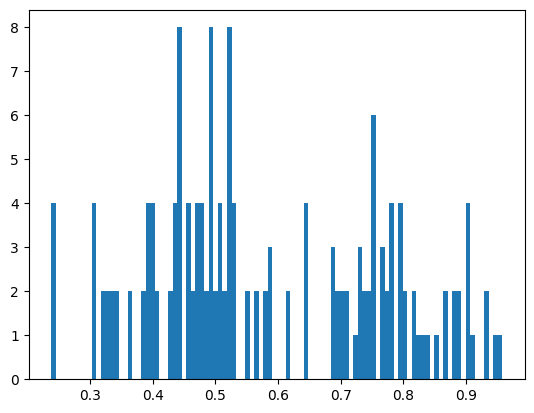

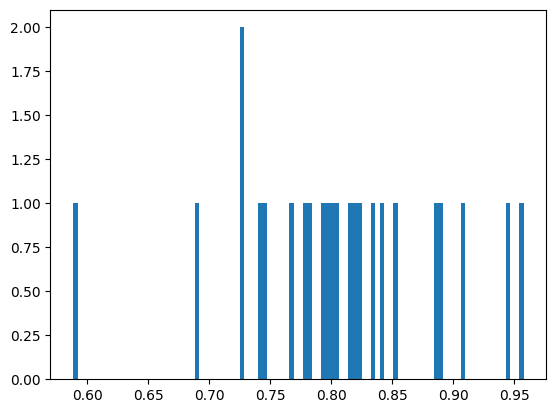

In [ ]:
import matplotlib.pyplot as plt

cosine_similarities_when_entailed = [x["scores"]["sim"] for x in entailments]
cosine_similarities_no_entailment = [x["scores"]["sim"] for x in no_entailments]

logprobs_when_entailed = [x["logprobs"] for x in entailments]
logprobs_no_entailment = [x["logprobs"] for x in no_entailments]


logprobs1_when_entailed = [x[0] for x in logprobs_when_entailed]
logprobs2_when_entailed = [x[1] for x in logprobs_when_entailed]

print(len([x for x in logprobs2_when_entailed if x > -0.3])/len(logprobs2_when_entailed))

# plt.hist(logprobs2_when_entailed, bins=1000)
# plt.show()

logprobs1_no_entailment = [x[0] for x in logprobs_no_entailment]
logprobs2_no_entailment = [x[1] for x in logprobs_no_entailment]

# plt.hist(logprobs2_no_entailment, bins=1000)
# plt.show()
print(len([x for x in logprobs2_no_entailment if x > -0.3])/len(logprobs2_no_entailment))


def test_filter_entailment(x, threshold, shorter):
    # if x["logprobs"][0] > -0.3:
    #     return True
    if x["scores"]["sim"] < threshold:
        return False
    if x["scores"]["shorter"] < shorter:
        return False
    return True
    
threshold = 0.5
shorter = -10
entailed_filtered = [x for x in entailments if test_filter_entailment(x, threshold=threshold, shorter=shorter)]
not_entailed_filtered = [x for x in no_entailments if test_filter_entailment(x, threshold=threshold, shorter=shorter)]


logprob_params = [-0.5, -0.4, -0.3, -0.2, -0.1]
threshold_params = [0.5, 0.6, 0.7]
shorter_params = [-20, -10, -5, 0]

# all_percentage_entailed_filtered = []
# all_percentage_not_entailed_filtered = []
# for logprob in logprob_params:
#     for threshold in threshold_params:
#         for shorter in shorter_params:
#             entailed_filtered = [x for x in entailments if filter_entailment(x, threshold=threshold, shorter=shorter)]
#             not_entailed_filtered = [x for x in no_entailments if filter_entailment(x, threshold=threshold, shorter=shorter)]
#             percentage_entailed_filtered = len(entailed_filtered)/len(entailments)*100
#             percentage_not_entailed_filtered = len(not_entailed_filtered)/len(no_entailments)*100
#             if percentage_entailed_filtered - percentage_not_entailed_filtered > 100:
#                 print(f"logprob: {logprob}, threshold: {threshold}, shorter: {shorter}")
#                 print(f"percentage_entailed_filtered: {percentage_entailed_filtered}, percentage_not_entailed_filtered: {percentage_not_entailed_filtered}")
#             all_percentage_entailed_filtered.append(percentage_entailed_filtered)
#             all_percentage_not_entailed_filtered.append(percentage_not_entailed_filtered)
            

# plt.plot(all_percentage_entailed_filtered, all_percentage_not_entailed_filtered)
# plt.show()

# find the entailed that are filtered out and check investigate what the pairs look like
entailed_filtered_out = [x for x in entailments if not filter_entailment(x, threshold=threshold, shorter=shorter)]
for x in entailed_filtered_out:
    print(x["text"])
    print(x["text_pair"])
    print("\n")


print(f"when entailment after filtering: {len(entailed_filtered)/len(entailments)*100}%")
print(f"no entailment after filtering: {len(not_entailed_filtered)/len(no_entailments)*100}%")
print(len(entailed_filtered))
print(len(not_entailed_filtered))
#plot histograms
plt.hist(cosine_similarities_no_entailment, bins=100)
plt.show()
plt.hist(cosine_similarities_when_entailed, bins=100)
plt.show()
# 86.84654300168634%
# 26.27055051504195%

In [ ]:
def visualize_hierarchy(matrix, clusters):
    dot = graphviz.Digraph(comment='My Hierarchical DAG', graph_attr={'rankdir': 'TB'})
    representatives = [c["representative"] for c in clusters]
    for i in range(len(representatives))    :
        dot.node(f'{representatives[i]["atomic_fact"]}', f'{representatives[i]["atomic_fact"]}')
        for j in range(len(representatives)):
            if i == j:
                continue
            elif matrix[i][j] > 0.5:
                rep = representatives[i]
                other_rep = representatives[j]
                dot.edge(f'{other_rep["atomic_fact"]}', f'{rep["atomic_fact"]}', label=f'{matrix[i][j]:.2f} ({matrix[j][i]:.2f})')
    return dot

dot = visualize_hierarchy(matrix, filtered_clusters)

# create png
dot.render('hierarchy', format='png')


dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.276702 to fit


'hierarchy.png'

In [ ]:
number_of_clusters_per_query = [len(q["clusters"]) for q in query_clusters]
print("Number of clusters per query: ", number_of_clusters_per_query)
print(sum([x for x in number_of_clusters_per_query]))

Number of clusters per query:  [6, 13, 17, 23, 37, 63, 48, 57, 47, 51, 71, 11, 10, 89, 56, 91, 91, 7, 103, 111, 124, 126, 85, 50, 103, 122, 10, 149, 100, 6, 169, 131, 142, 160, 136, 13, 75, 170, 18, 86, 175, 88, 157, 123, 151, 163, 160, 189, 154, 212, 138, 9, 173, 220, 170, 161, 217, 184, 171, 181, 213, 167, 35, 72, 186, 56, 194, 71, 165, 183, 157, 74, 14, 177, 46, 49, 192, 82, 178, 83, 184, 41, 193, 227, 174, 117, 152, 53, 44, 111, 51, 73, 36, 126, 143, 11, 128, 137, 170, 153, 160, 113, 137, 41, 143, 107, 50, 91, 109, 219, 77, 107, 157, 189, 188, 214, 211, 192, 193, 134, 122, 105, 137, 192, 153, 3, 124, 13, 61, 67, 155, 163, 91, 208, 180, 170, 130, 76, 14, 149, 111, 107, 165, 165, 30, 172, 80, 141, 180, 168, 139, 129, 147, 134, 157, 157, 213, 107, 210, 203, 200, 153, 158, 172, 203, 143, 181, 138, 142, 63, 15, 100, 66, 161, 141, 94, 13, 56, 189, 146, 145, 123, 226, 140, 180, 78, 74, 155, 162, 115, 229, 212, 118, 144, 173, 228, 79, 202, 182, 161, 122, 152, 18, 136, 200, 159, 141, 146, 1

In [ ]:
to_embed = []
for query in query_clusters:
    for cluster in query["clusters"]:
        for atomic_fact in cluster["atomic_facts"]:
            to_embed.append(atomic_fact["atomic_fact"])

results = embedding_model.encode(
    to_embed,
    batch_size=64,          # optional
    show_progress_bar=True, # <-- adds a live tqdm bar
)


counter = 0
for query in query_clusters:
    for i, cluster in enumerate(query["clusters"]):
        for j, atomic_fact in enumerate(cluster["atomic_facts"]):
            atomic_fact["embedding"] = results[counter]
            counter += 1


Batches:   0%|          | 0/1948 [00:00<?, ?it/s]

In [ ]:
import numpy as np
# for each cluster, find the smallest cosine similarity within the cluster
smallest_similarity = 1.0
smallest_cluster = None
identical_facts = 0
similarities_within_cluster = []
for query in query_clusters:
    for cluster in query["clusters"]:
        min_similarity = 1.0
        if len(cluster["atomic_facts"]) < 2:
            continue
        for i, atomic_fact in enumerate(cluster["atomic_facts"]):
            for j, other_atomic_fact in enumerate(cluster["atomic_facts"]):
                if i == j:
                    continue
                if atomic_fact["atomic_fact"] == other_atomic_fact["atomic_fact"]:
                    identical_facts += 1
                similarity = np.dot(atomic_fact["embedding"], other_atomic_fact["embedding"]) / (np.linalg.norm(atomic_fact["embedding"]) * np.linalg.norm(other_atomic_fact["embedding"]))
                similarities_within_cluster.append(similarity)
                if similarity < min_similarity:
                    min_similarity = similarity
                    smallest_cluster = cluster
        if min_similarity < smallest_similarity:
            smallest_similarity = min_similarity
            smallest_cluster = cluster
print(smallest_similarity)
for fact in smallest_cluster["atomic_facts"]:
    print(fact["atomic_fact"])
print()



0.58559436
Lou Briel performed at the Show Time nightspot in 2006.
Lou Briel performed at the "Show Time" nightspot in 2006.



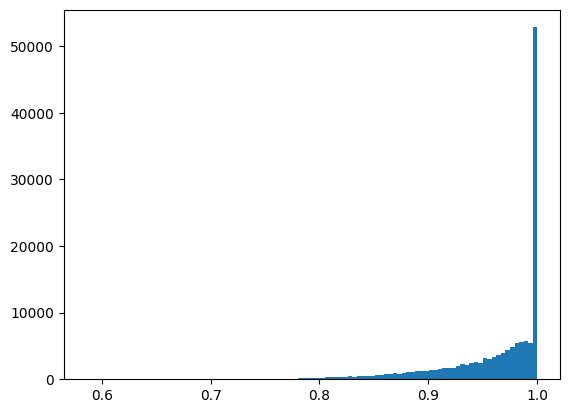

2344
1.6315620954157561
34.06373115420489


In [ ]:
import matplotlib.pyplot as plt
plt.hist(similarities_within_cluster, bins=100)
plt.show()

filtered = [x for x in similarities_within_cluster if x < 0.8]
print(len(filtered))
print(len(filtered)/len(similarities_within_cluster)*100)

percentage_identical_facts = identical_facts/len(similarities_within_cluster)*100
print(percentage_identical_facts)




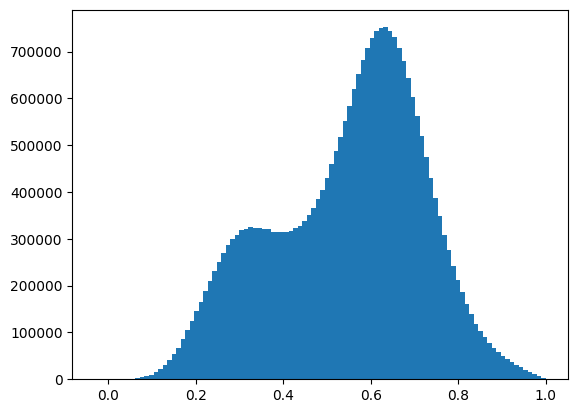

In [ ]:
similarities_outside_cluster = []
for query in query_clusters:
    for cluster in query["clusters"]:
        for atomic_fact in cluster["atomic_facts"]:
            for other_cluster in query["clusters"]:
                if other_cluster == cluster:
                    continue
                for other_atomic_fact in other_cluster["atomic_facts"]:
                    similarity = np.dot(atomic_fact["embedding"], other_atomic_fact["embedding"]) / (np.linalg.norm(atomic_fact["embedding"]) * np.linalg.norm(other_atomic_fact["embedding"]))
                    similarities_outside_cluster.append(similarity)

plt.hist(similarities_outside_cluster, bins=100)
plt.show()


In [ ]:
after_filtering = [x for x in similarities_outside_cluster if x < 0.8]
print(len(after_filtering))
print(len(after_filtering)/len(similarities_outside_cluster)*100)










25709860
95.10630804993644
